In [1]:
!pip install pymysql sqlalchemy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00


In [7]:
import matplotlib.pyplot as plt

# Подключение и загрузка данных

In [2]:
import pandas as pd
from sqlalchemy import create_engine

host = "95.131.149.21"
port = 3306
database = "mgpu_ico_etl_01"
username = "mgpu_ico_etl_01"
password = "UzE1ZFQt"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

query = """
SELECT *
FROM view_sales_report_lw3
"""

df = pd.read_sql(query, engine)
df.head()

,customer_name,category,total_sales,transactions_count,total_quantity
0,Barbara Miller,Clothing,690.0,3,4.0
1,Michelle Scott,Home,180.0,1,4.0
2,Barbara Mitchell,Clothing,1800.0,5,13.0
3,John Rivera,Home,45.0,1,1.0
4,Michael Clark,Sports,60.0,1,2.0


# Подготовка агрегатов





In [5]:
# Продажи по категориям
category_sales = (
    df.groupby("category", as_index=False)
      .agg({
          "total_sales": "sum",
          "transactions_count": "sum",
          "total_quantity": "sum"
      })
      .sort_values("total_sales", ascending=False)
)

# Топ-10 клиентов по сумме продаж
top_customers = (
    df.groupby("customer_name", as_index=False)
      .agg({
          "total_sales": "sum",
          "transactions_count": "sum",
          "total_quantity": "sum"
      })
      .sort_values("total_sales", ascending=False)
      .head(10)
)

category_sales

,category,total_sales,transactions_count,total_quantity
2,Electronics,1691376.0,987,1924.0
3,Home,580500.0,1007,1970.0
1,Clothing,218455.0,1000,1982.0
4,Sports,139955.0,994,1961.0
0,Beauty,74219.0,1012,1941.0


# График 1 — сумма продаж по категориям

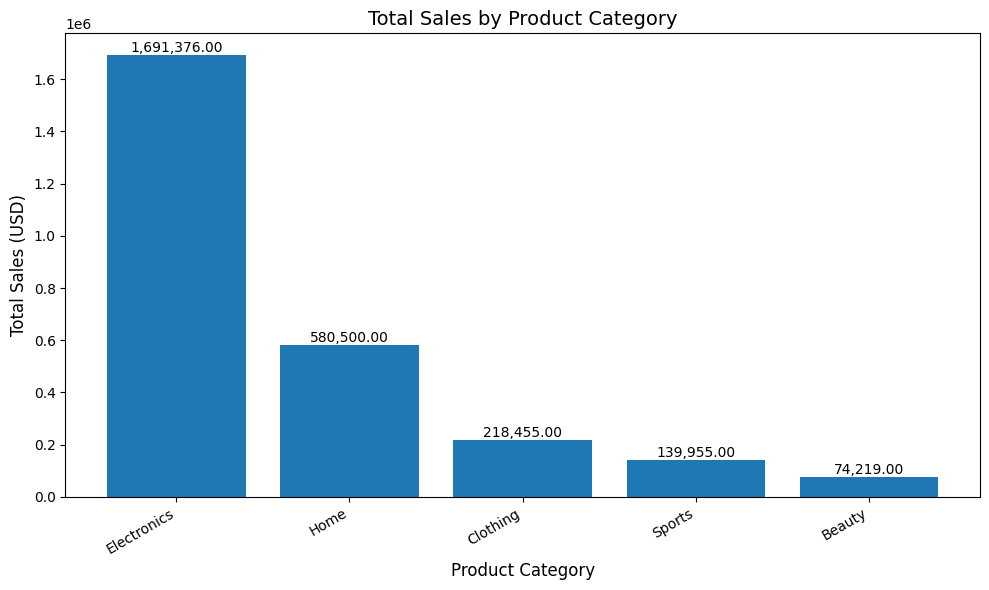

In [8]:
plt.figure(figsize=(10, 6))

bars = plt.bar(category_sales["category"], category_sales["total_sales"])

plt.title("Total Sales by Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales (USD)", fontsize=12)
plt.xticks(rotation=30, ha="right")

# Подписи значений над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# График 2 — количество транзакций по категориям (сколько покупок сделали)

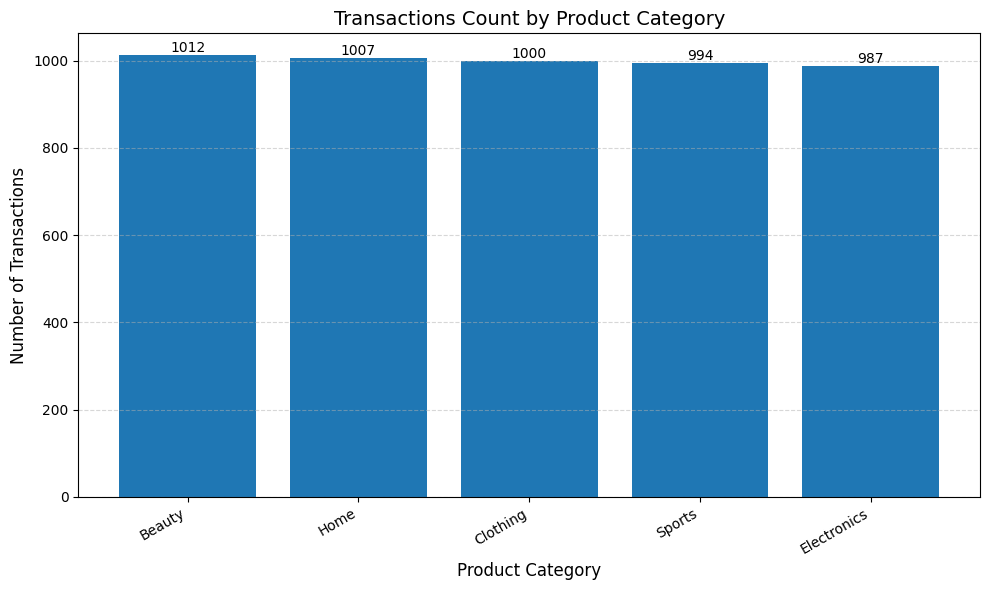

In [11]:
category_tx = (
    df.groupby("category", as_index=False)["transactions_count"]
      .sum()
      .sort_values("transactions_count", ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(category_tx["category"], category_tx["transactions_count"])

plt.title("Transactions Count by Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# График 3 — объем проданных товаров по категориямс (сколько товаров купили)

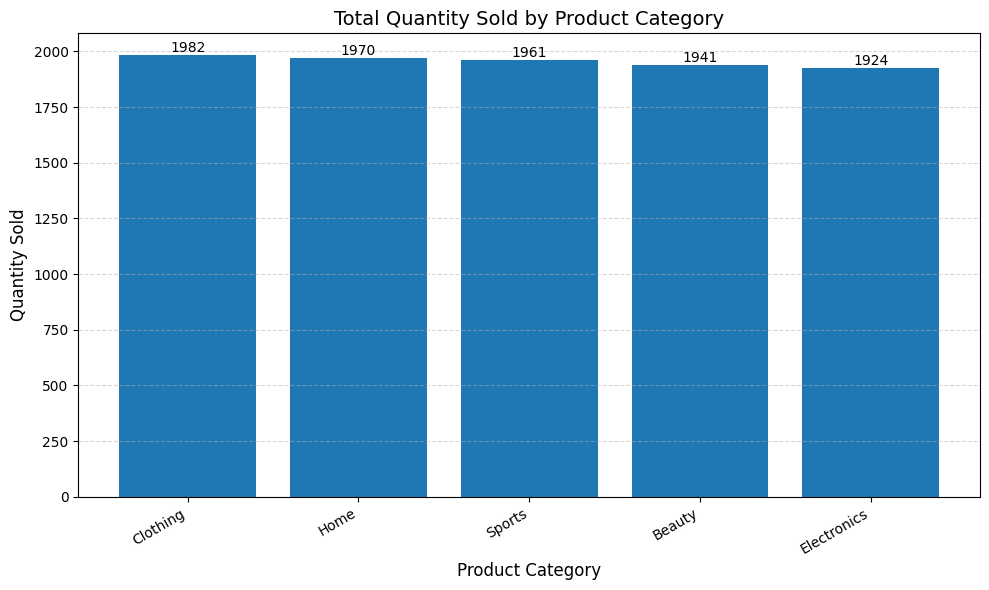

In [13]:
category_qty = (
    df.groupby("category", as_index=False)["total_quantity"]
      .sum()
      .sort_values("total_quantity", ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(category_qty["category"], category_qty["total_quantity"])

plt.title("Total Quantity Sold by Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# График 4 — топ-10 клиентов по сумме продаж

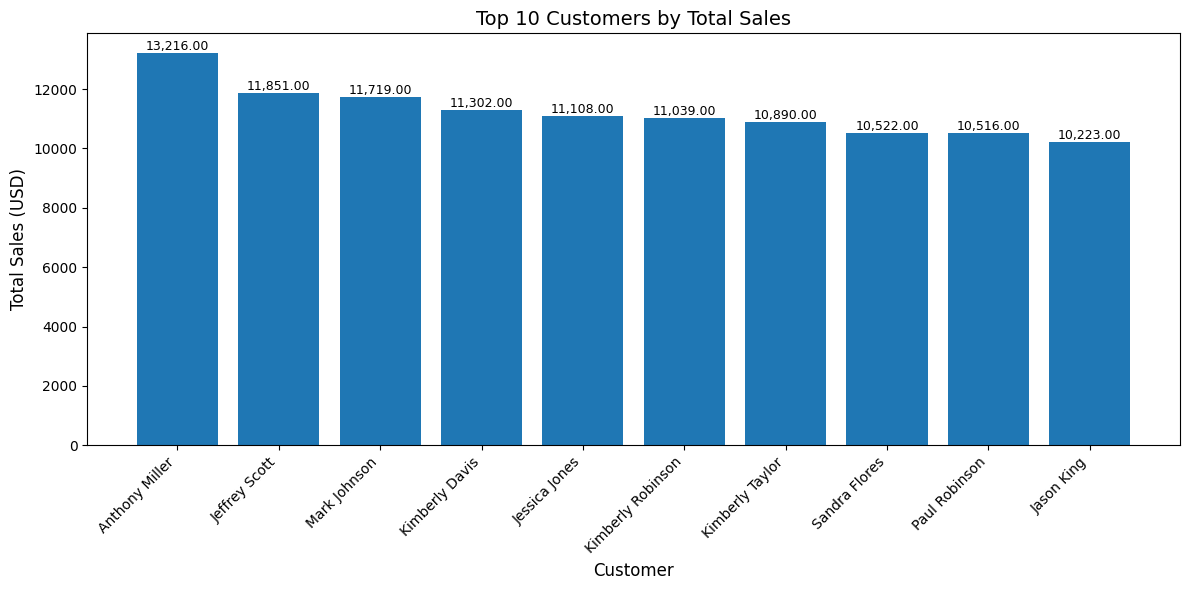

In [9]:
plt.figure(figsize=(12, 6))

bars = plt.bar(top_customers["customer_name"], top_customers["total_sales"])

plt.title("Top 10 Customers by Total Sales", fontsize=14)
plt.xlabel("Customer", fontsize=12)
plt.ylabel("Total Sales (USD)", fontsize=12)
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Вывод по результатам анализа

Проведенный анализ показал, что наибольший вклад в выручку вносит категория Electronics, значительно опережая остальные категории по сумме продаж. Это свидетельствует о высокой стоимости товаров данной категории и их значимости для бизнеса.

При этом распределение количества транзакций по категориям является практически равномерным, что говорит о сопоставимой частоте покупок во всех товарных группах. Однако различия в суммарной выручке обусловлены различной стоимостью товаров.

Анализ общего количества проданных товаров показывает, что объем продаж в штуках также распределен достаточно равномерно, что подтверждает стабильный спрос на все категории.

Дополнительно было выявлено, что основную часть выручки формируют отдельные клиенты — топ-10 покупателей, что позволяет выделить наиболее ценных клиентов для дальнейшего анализа и возможных маркетинговых стратегий.